In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

import optuna

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
df = pd.read_csv('healthcare_heart_risk.csv')

print(df.head())
print(df.info())
print(df.describe())

   patient_id  age   bmi  blood_pressure  glucose_level  cholesterol  \
0       50001   71  21.7             100            136          172   
1       50002   34  22.0             166            196          172   
2       50003   80  26.5              92            124          293   
3       50004   40  26.9              98            178          158   
4       50005   43  37.2             149            167          162   

  smoking_status physical_activity  family_history  heart_disease_risk  
0          Never               Low               0                   0  
1         Former              High               1                   1  
2          Never          Moderate               0                   0  
3        Current              High               0                   0  
4        Current               Low               0                   1  
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column              Non-Null

In [17]:
# Encode categorical columns automatically
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

target_column = "heart_disease_risk"   # CHANGE if needed

X = df.drop(target_column, axis=1)
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Report")
print(classification_report(y_test, y_pred_dt))

Decision Tree Report
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       279
           1       0.98      1.00      0.99       121

    accuracy                           0.99       400
   macro avg       0.99      1.00      0.99       400
weighted avg       1.00      0.99      1.00       400



In [19]:
param_grid = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_dt = grid.best_estimator_

print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV Score: 0.9855241114804574


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
def build_model(neurons=64, dropout_rate=0.3, learning_rate=0.001):
    model = keras.Sequential([
        layers.Dense(neurons, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001),
                     input_shape=(X_train_scaled.shape[1],)),
        layers.Dropout(dropout_rate),
        
        layers.Dense(neurons//2, activation='relu'),
        layers.Dropout(dropout_rate),
        
        layers.Dense(1, activation='sigmoid')
    ])

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_model()

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6844 - loss: 0.6065 - val_accuracy: 0.7063 - val_loss: 0.5255
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7609 - loss: 0.4854 - val_accuracy: 0.8375 - val_loss: 0.4115
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8430 - loss: 0.3930 - val_accuracy: 0.8844 - val_loss: 0.3169
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8625 - loss: 0.3283 - val_accuracy: 0.8938 - val_loss: 0.2671
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8766 - loss: 0.3008 - val_accuracy: 0.9062 - val_loss: 0.2455
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8813 - loss: 0.2945 - val_accuracy: 0.9062 - val_loss: 0.2359
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8820 - loss: 0.2742 - val_accuracy: 0.9000 - val_loss: 0.2320
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8906 - loss: 0.2635 - val_accuracy: 0.8906 - val_loss: 0.2305
Epo

In [22]:
y_pred_ann = (model.predict(X_test_scaled) > 0.5).astype(int)

print("ANN Classification Report")
print(classification_report(y_test, y_pred_ann))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
ANN Classification Report
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       279
           1       0.85      0.86      0.86       121

    accuracy                           0.91       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.91      0.91      0.91       400



In [23]:
def objective(trial):
    
    neurons = trial.suggest_int("neurons", 32, 256)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    
    model = build_model(neurons, dropout_rate, learning_rate)
    
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )
    
    return max(history.history['val_accuracy'])

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best Trial:", study.best_trial.params)

[I 2026-03-03 15:38:31,040] A new study created in memory with name: no-name-30216583-8c24-479c-a945-07641d8181de
C:\Users\User\AppData\Local\Temp\ipykernel_6520\2753539746.py:5: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("learning_rate", 1e-4, 1e-2)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
[I 2026-03-03 15:38:39,556] Trial 0 finished with value: 0.8968750238418579 and parameters: {'neurons': 75, 'dropout_rate': 0.12070582553829992, 'learning_rate': 0.0001527501723456

Best Trial: {'neurons': 132, 'dropout_rate': 0.21083304963784494, 'learning_rate': 0.0022721023855808895, 'batch_size': 32}


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


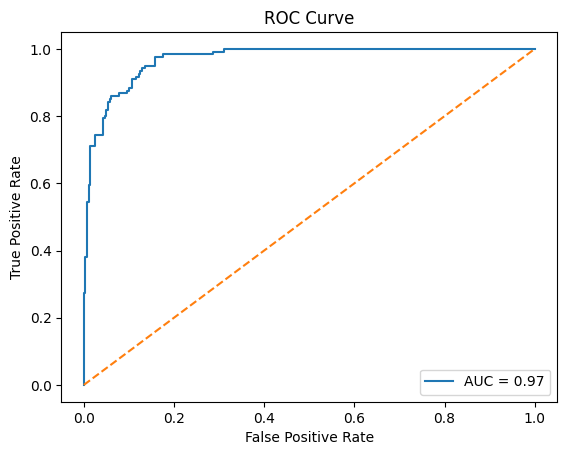

In [24]:
y_probs = model.predict(X_test_scaled)

fpr, tpr, _ = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()